In [34]:
import pandas as pd
df = pd.read_csv('delhi_water_data.csv', encoding= 'unicode_escape')

In [35]:
df.head()

,Temp,D.O. (mg/l),PH,B.O.D. (mg/l),TOTAL COLIFORM (MPN/100ml)Mean
0,30.6,6.7,7.5,NAN,27
1,29.8,5.7,7.2,2,8391
2,29.5,6.3,6.9,1.7,5330
3,29.7,5.8,6.9,3.8,8443
4,29.5,5.8,7.3,1.9,5500


In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1991 entries, 0 to 1990
Data columns (total 5 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   Temp                            1991 non-null   object
 1   D.O. (mg/l)                     1991 non-null   object
 2   PH                              1991 non-null   object
 3   B.O.D. (mg/l)                   1991 non-null   object
 4   TOTAL COLIFORM (MPN/100ml)Mean  1991 non-null   object
dtypes: object(5)
memory usage: 77.9+ KB


In [37]:
df.iloc[1900:].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91 entries, 1900 to 1990
Data columns (total 5 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   Temp                            91 non-null     object
 1   D.O. (mg/l)                     91 non-null     object
 2   PH                              91 non-null     object
 3   B.O.D. (mg/l)                   91 non-null     object
 4   TOTAL COLIFORM (MPN/100ml)Mean  91 non-null     object
dtypes: object(5)
memory usage: 3.7+ KB


In [38]:
df.iloc[1900:].describe()

,Temp,D.O. (mg/l),PH,B.O.D. (mg/l),TOTAL COLIFORM (MPN/100ml)Mean
count,91,91,91,91,91
unique,15,21,83,49,86
top,28,7,76,1.2,1350
freq,21,11,2,6,2


In [39]:
df.tail()

,Temp,D.O. (mg/l),PH,B.O.D. (mg/l),TOTAL COLIFORM (MPN/100ml)Mean
1986,NAN,7.9,738,2.7,202
1987,29,7.5,585,2.6,315
1988,28,7.6,98,1.2,570
1989,28,7.7,91,1.3,562
1990,29,7.6,110,1.1,546


In [40]:
df['Temp'].value_counts()

Temp
28        241
29        163
27        161
26        102
NAN        88
         ... 
25.667      1
21.2        1
31.1        1
27.714      1
14          1
Name: count, Length: 179, dtype: int64

In [41]:
df.shape

(1991, 5)

In [42]:
df.dtypes

Temp                              object
D.O. (mg/l)                       object
PH                                object
B.O.D. (mg/l)                     object
TOTAL COLIFORM (MPN/100ml)Mean    object
dtype: object

In [43]:
# Changing column names
df = df.rename(columns={"D.O. (mg/l)": "DO","B.O.D. (mg/l)": "BOD","TOTAL COLIFORM (MPN/100ml)Mean": "Tot_col"})

In [44]:
df.head()

,Temp,DO,PH,BOD,Tot_col
0,30.6,6.7,7.5,NAN,27
1,29.8,5.7,7.2,2,8391
2,29.5,6.3,6.9,1.7,5330
3,29.7,5.8,6.9,3.8,8443
4,29.5,5.8,7.3,1.9,5500


In [45]:
# Converting object data type to numeric
df = df.apply(pd.to_numeric, errors='coerce')
df.dtypes


Temp       float64
DO         float64
PH         float64
BOD        float64
Tot_col    float64
dtype: object

In [46]:
df.head()

,Temp,DO,PH,BOD,Tot_col
0,30.6,6.7,7.5,NaN,27.0
1,29.8,5.7,7.2,2.0,8391.0
2,29.5,6.3,6.9,1.7,5330.0
3,29.7,5.8,6.9,3.8,8443.0
4,29.5,5.8,7.3,1.9,5500.0


In [47]:
# Replacing string NAN values with actual NAN value (np.nan)
import numpy as np
df = df.replace(["NAN", "nan", "NaN", "NA"], np.nan)

In [48]:
df.head()

,Temp,DO,PH,BOD,Tot_col
0,30.6,6.7,7.5,NaN,27.0
1,29.8,5.7,7.2,2.0,8391.0
2,29.5,6.3,6.9,1.7,5330.0
3,29.7,5.8,6.9,3.8,8443.0
4,29.5,5.8,7.3,1.9,5500.0


In [49]:
df.isnull().sum()

Temp        92
DO          31
PH           8
BOD         43
Tot_col    132
dtype: int64

In [50]:
# Replacing NULL values with median of column
# Selecting numeric data
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

df = pd.DataFrame(imputer.fit_transform(df),columns=df.columns,index=df.index)

In [51]:
df.head()

,Temp,DO,PH,BOD,Tot_col
0,30.6,6.7,7.5,1.8965,27.0
1,29.8,5.7,7.2,2.0000,8391.0
2,29.5,6.3,6.9,1.7000,5330.0
3,29.7,5.8,6.9,3.8000,8443.0
4,29.5,5.8,7.3,1.9000,5500.0


In [52]:
df.isnull().sum()

Temp       0
DO         0
PH         0
BOD        0
Tot_col    0
dtype: int64

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

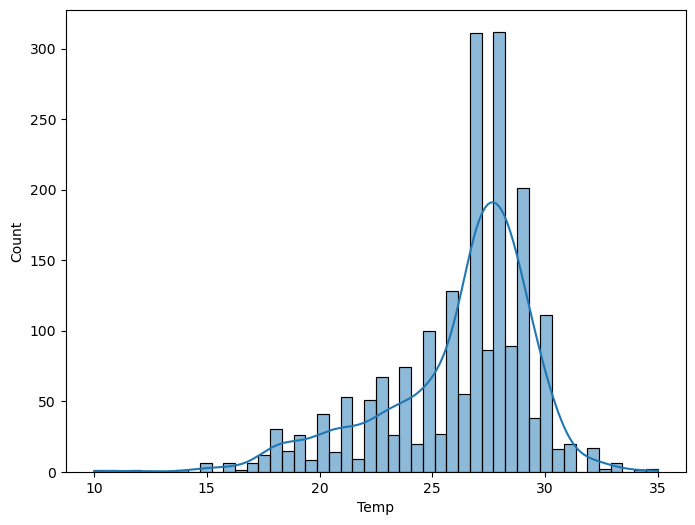

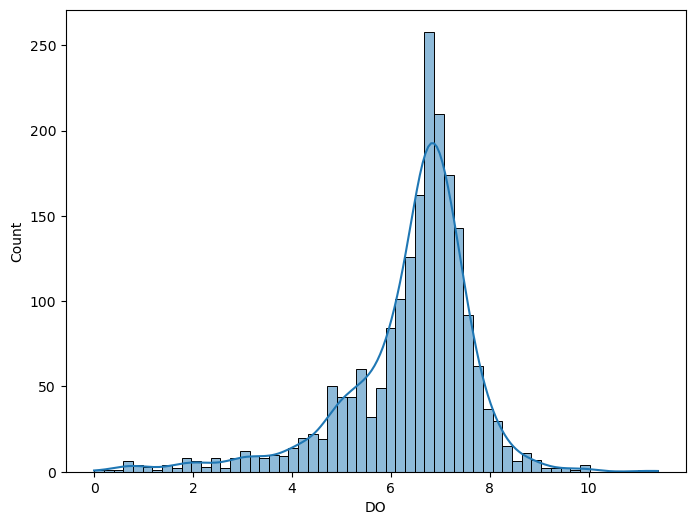

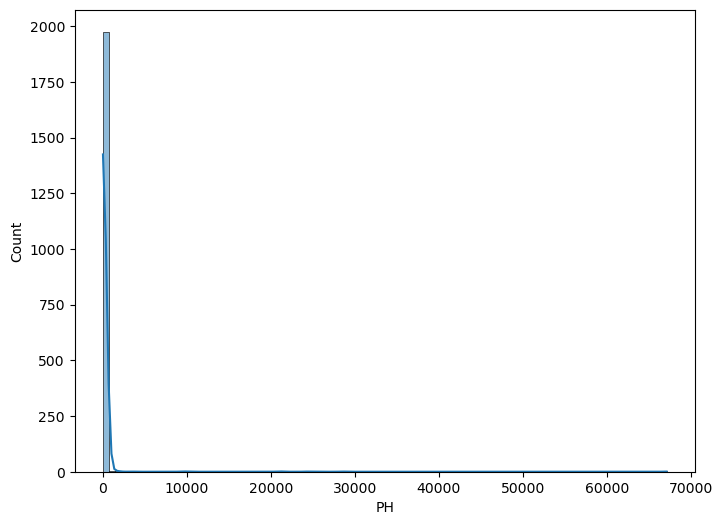

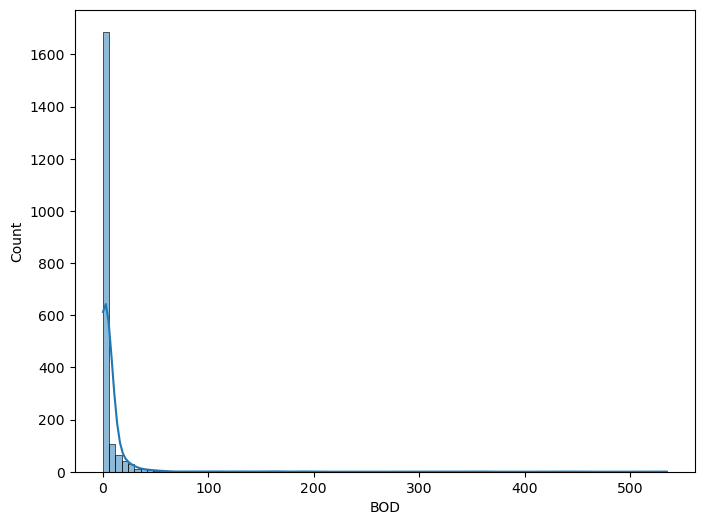

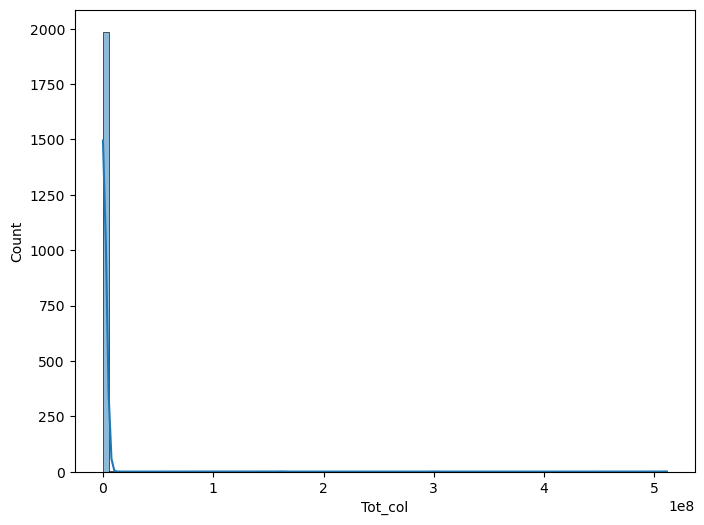

In [54]:
def plot_kde(df):
    for col in df.columns:
        plt.figure(figsize=(8, 6))
        sns.histplot(data=df, x = col, kde=True)
plot_kde(df)

In [55]:
# Here, almost all kde plots are Gaussian Like 
# Using Z-Score Normalization to detect outliers

# df_num_final_norm = zscore(df_num_final, axis=0)


# def indices_of_greater_than_3(arr):
#     indices_arr = []
#     n_col = arr.shape[1]

#     for col in range(n_col):
#         greater_than_3_index = np.where(arr[:, col] > 3)[0]
#         indices_arr.extend(greater_than_3_index)

#     return indices_arr

# indices_arr = indices_of_greater_than_3(df_num_final_norm)
# print("Number of outliers using Z-Score method-",len(indices_arr))
# df_final.iloc[indices_arr, :]
df.skew()

Temp       -1.126522
DO         -1.468481
PH         27.343852
BOD        12.397680
Tot_col    31.714072
dtype: float64

In [56]:
df['PH'].describe()

count     1991.000000
mean       111.669617
std       1875.161891
min          0.000000
25%          6.900000
50%          7.300000
75%          7.700000
max      67115.000000
Name: PH, dtype: float64

In [57]:
df[df['PH'] > 14]

,Temp,DO,PH,BOD,Tot_col
1901,30.0,7.8,239.0,1.7,10720.0
1902,29.0,7.5,442.0,3.4,132.0
1903,29.0,7.0,430.0,2.4,175.0
1904,29.0,7.2,216.0,1.8,167.0
1905,29.0,7.9,352.0,4.2,158.0
...,...,...,...,...,...
1986,27.0,7.9,738.0,2.7,202.0
1987,29.0,7.5,585.0,2.6,315.0
1988,28.0,7.6,98.0,1.2,570.0
1989,28.0,7.7,91.0,1.3,562.0


In [58]:
# Selecting 1900 samples, because samples having indices greater than 1900 are not correct (pH > 14)
df = df.iloc[0:1900, :]

In [59]:
df.skew()

Temp       -1.114863
DO         -1.428456
PH         -3.080485
BOD        12.235422
Tot_col    30.979790
dtype: float64

In [60]:
df[df['PH'] < 0]

,Temp,DO,PH,BOD,Tot_col


<Axes: xlabel='PH', ylabel='Count'>

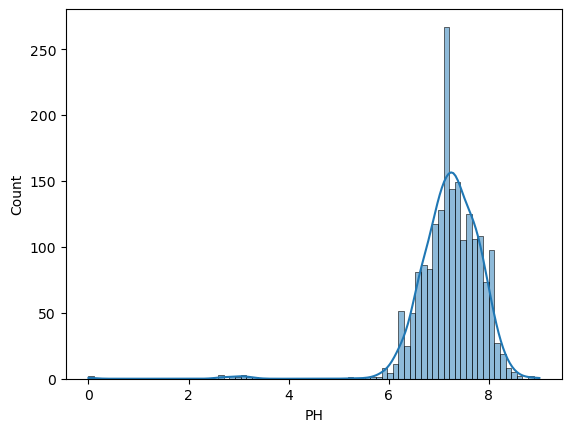

In [61]:
sns.histplot(data=df, x='PH', kde=True)

<Axes: xlabel='PH'>

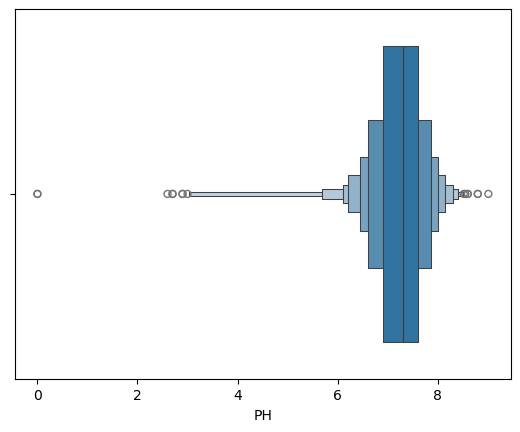

In [62]:
sns.boxenplot(data=df, x='PH')

In [63]:
df['BOD'].describe()

count    1900.000000
mean        6.748219
std        27.391274
min         0.100000
25%         1.200000
50%         1.896500
75%         3.600000
max       534.500000
Name: BOD, dtype: float64

In [64]:
df['BOD_log'] = np.log1p(df['BOD'])

<Axes: xlabel='BOD_log', ylabel='Count'>

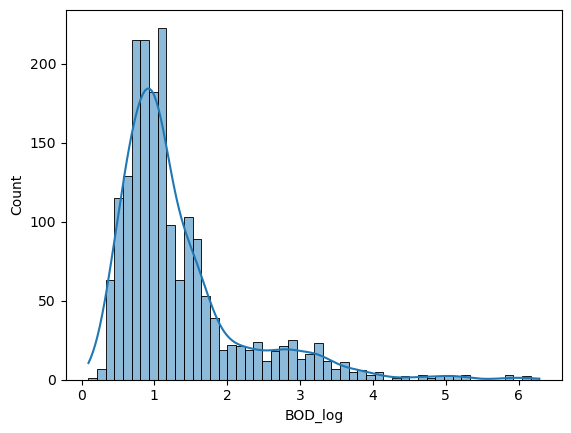

In [65]:
sns.histplot(data=df, x='BOD_log', kde=True)

In [66]:
df['BOD_log'].describe()

count    1900.000000
mean        1.311454
std         0.859981
min         0.095310
25%         0.788457
50%         1.063503
75%         1.526056
max         6.283201
Name: BOD_log, dtype: float64

In [67]:
df.head()

,Temp,DO,PH,BOD,Tot_col,BOD_log
0,30.6,6.7,7.5,1.8965,27.0,1.063503
1,29.8,5.7,7.2,2.0000,8391.0,1.098612
2,29.5,6.3,6.9,1.7000,5330.0,0.993252
3,29.7,5.8,6.9,3.8000,8443.0,1.568616
4,29.5,5.8,7.3,1.9000,5500.0,1.064711


In [68]:
df['Tot_col_log'] = np.log1p(df['Tot_col'])

In [69]:
df['Tot_col_log'].describe()

count    1900.000000
mean        6.270086
std         2.236096
min         0.000000
25%         4.751426
50%         6.150603
75%         7.450078
max        20.052058
Name: Tot_col_log, dtype: float64

<Axes: xlabel='Tot_col_log'>

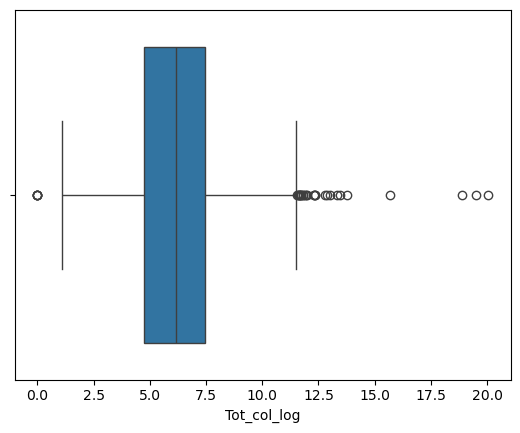

In [70]:
sns.boxplot(data=df, x='Tot_col_log')

<Axes: xlabel='Tot_col_log', ylabel='Count'>

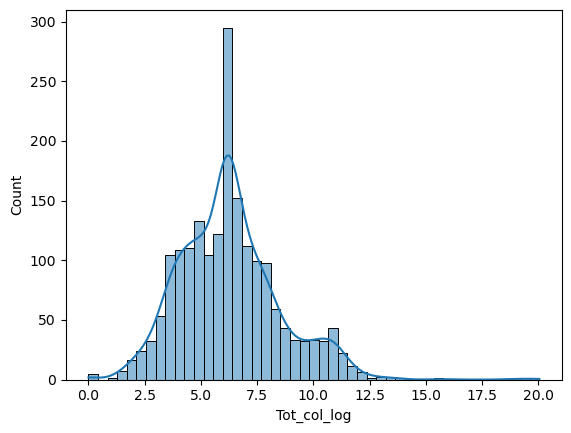

In [71]:
sns.histplot(data=df, x='Tot_col_log', kde=True)

In [72]:
df.head()

,Temp,DO,PH,BOD,Tot_col,BOD_log,Tot_col_log
0,30.6,6.7,7.5,1.8965,27.0,1.063503,3.332205
1,29.8,5.7,7.2,2.0000,8391.0,1.098612,9.035034
2,29.5,6.3,6.9,1.7000,5330.0,0.993252,8.581294
3,29.7,5.8,6.9,3.8000,8443.0,1.568616,9.041211
4,29.5,5.8,7.3,1.9000,5500.0,1.064711,8.612685


In [73]:
df.describe()

,Temp,DO,PH,BOD,Tot_col,BOD_log,Tot_col_log
count,1900.000000,1900.000000,1900.000000,1900.000000,1.900000e+03,1900.000000,1900.000000
mean,26.231283,6.360088,7.228177,6.748219,5.221256e+05,1.311454,6.270086
std,3.298729,1.334036,0.649026,27.391274,1.408000e+07,0.859981,2.236096
min,10.000000,0.000000,0.000000,0.100000,0.000000e+00,0.095310,0.000000
25%,25.000000,5.900000,6.900000,1.200000,1.147500e+02,0.788457,4.751426
50%,27.000000,6.700000,7.300000,1.896500,4.680000e+02,1.063503,6.150603
75%,28.300000,7.100000,7.600000,3.600000,1.719000e+03,1.526056,7.450078
max,35.000000,11.400000,9.010000,534.500000,5.110909e+08,6.283201,20.052058


In [75]:
df.head()

,Temp,DO,PH,BOD,Tot_col,BOD_log,Tot_col_log
0,30.6,6.7,7.5,1.8965,27.0,1.063503,3.332205
1,29.8,5.7,7.2,2.0000,8391.0,1.098612,9.035034
2,29.5,6.3,6.9,1.7000,5330.0,0.993252,8.581294
3,29.7,5.8,6.9,3.8000,8443.0,1.568616,9.041211
4,29.5,5.8,7.3,1.9000,5500.0,1.064711,8.612685


In [77]:
df_final1 = df.drop([ 'BOD_log','Tot_col_log'], axis=1)

In [78]:
df_final1.head()

,Temp,DO,PH,BOD,Tot_col
0,30.6,6.7,7.5,1.8965,27.0
1,29.8,5.7,7.2,2.0000,8391.0
2,29.5,6.3,6.9,1.7000,5330.0
3,29.7,5.8,6.9,3.8000,8443.0
4,29.5,5.8,7.3,1.9000,5500.0


In [81]:
df_final1.shape

(1900, 5)

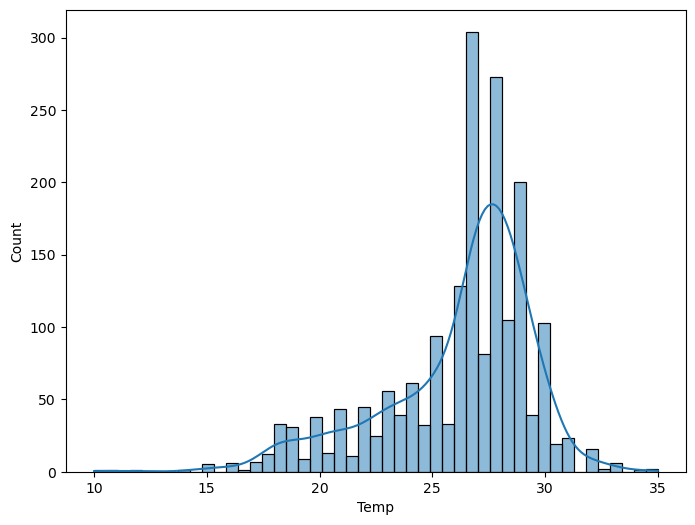

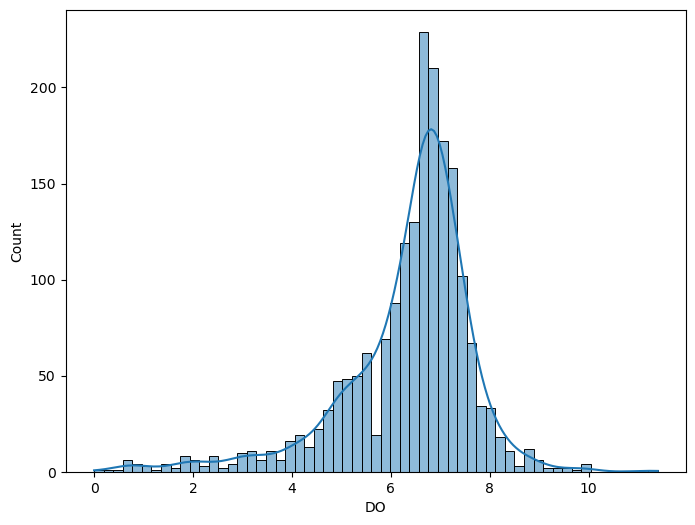

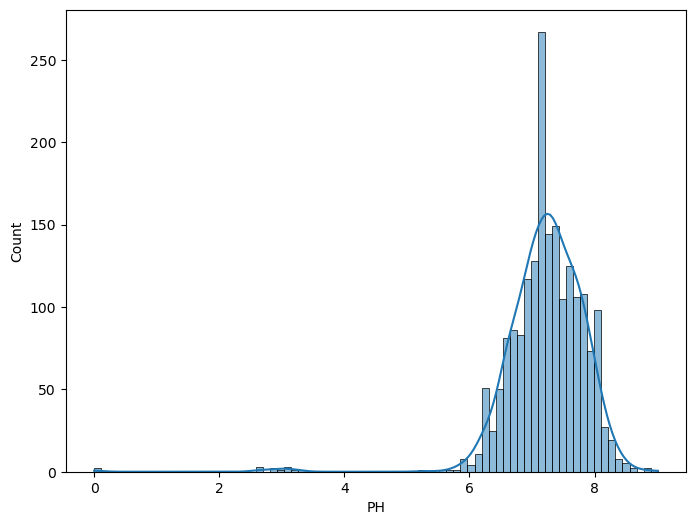

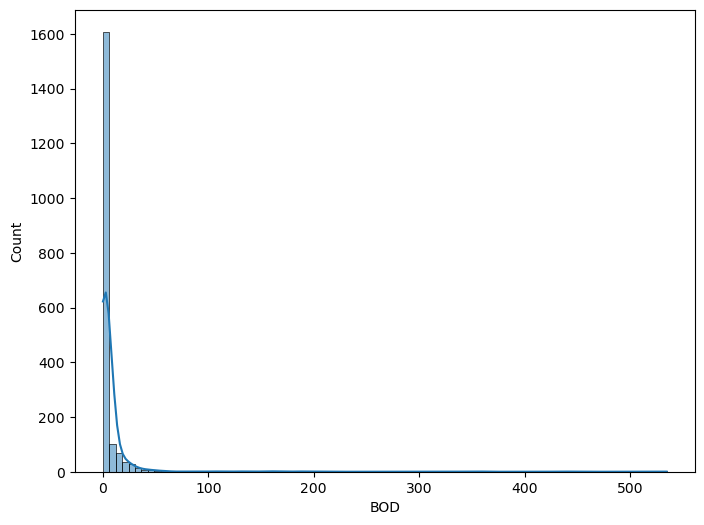

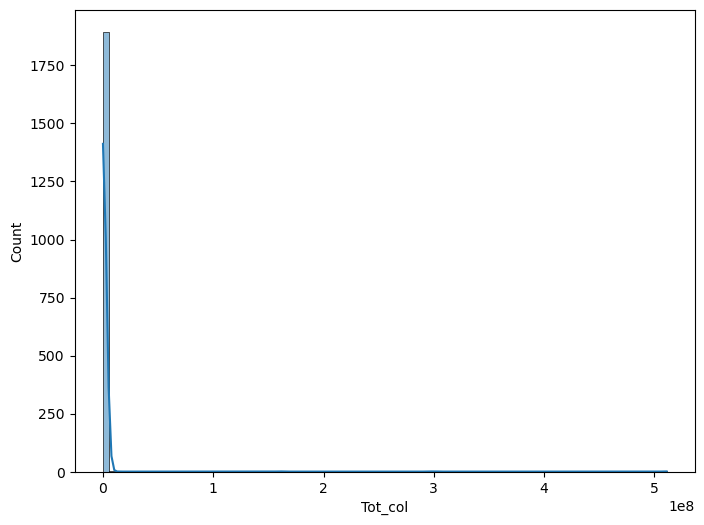

In [82]:
plot_kde(df_final1.select_dtypes(exclude=object))

## Water Quality Index Calculation

I will be using "Weighted Arithmetic Water Quality Index Method" to calculate WQI of each water sample. The formula to calculate WQI is - 

**WQI = ∑ qi × wi / ∑ wi**

     Here wi - Unit weight of ith parameter

     qi - Quality estimate/index or subindex of each parameter, it is calculated with the formula - 

**qi = 100 × ( Vi − Videal / Si − Videal )**

     Here Vi - Measured value of ith parameter

     Videal - Ideal value of ith parameter in pure water
     
     Si - Standard value recommended for ith parameter

wi is calculated by the formula - 

**wi = K /  Si**

  Here K is proportionality constant which is - 

 **K = 1 /  ∑ (1 / Si)**

##### Standard value recommended for parameters (Si) - 

Dissolved oxygen, mg/L  :          5

pH                       :            8.5

Biological oxygen demand, mg/L  :       3

Total coliform/100 mL    :             500

##### For k=1.5314 Values of unit weights for each parameter (wi) - 

Dissolved Oxygen :                     0.3063

pH :                                   0.1802

Biological Oxygen Demand :             0.5105

Total Coliform :                      0.0031

##### Ideal value of parameters (Videal) - 

Dissolved Oxygen :                     DOsat

pH :                                 7.0

Biological Oxygen Demand :           0

Total Coliform :                      0

where  DOsat ​= 14.621 − 0.41022T \+ 0.00799T2 − 0.0000774T3

In [83]:
df_final1 = df_final1.select_dtypes(exclude="object")

#weight vector(wi)
wi = np.array([0.3063, 0.1802, 0.5105, 0.0031])

def calculate_DO_saturation(t):
    dosat = 14.621 - 0.41022*t + 0.00799*t*t - 0.0000774*t*t*t
    return dosat
# Temp	DO	PH	BOD	Tot_col
def calc_wqi(sample):
    temp = sample["Temp"]
    do = sample["DO"]
    ph = sample["PH"]
    bod = sample["BOD"]
    tc = sample["Tot_col"]

    do_sat = calculate_DO_saturation(temp)

    q_do = 100 * ((do_sat - do) / (do_sat - 5))

    q_ph = 100 * abs(ph - 7) / (8.5 - 7)

    q_bod = 100 * bod / 3

    q_tc = 100 * tc / 500

    wqi = (
        q_do * wi[0] +
        q_ph * wi[1] +
        q_bod * wi[2] +
        q_tc * wi[3]
    )

    return wqi

In [84]:
# Computing WQI for the whole dataset
df_final1["WQI"] = df_final1.apply(calc_wqi, axis=1)

In [85]:
df_final1.head()

,Temp,DO,PH,BOD,Tot_col,WQI
0,30.6,6.7,7.5,1.8965,27.0,46.597301
1,29.8,5.7,7.2,2.0000,8391.0,63.494076
2,29.5,6.3,6.9,1.7000,5330.0,48.045460
3,29.7,5.8,6.9,3.8000,8443.0,91.758762
4,29.5,5.8,7.3,1.9000,5500.0,60.117939


In [87]:
df_final1['WQI'].describe()

count      1900.000000
mean        460.733757
std        8826.495214
min         -22.544992
25%          36.864418
50%          52.708890
75%          88.237872
max      318730.942567
Name: WQI, dtype: float64

In [88]:
df_final1.to_csv('data2.csv', index=False)

In [89]:
# df_final1 = df_final1.drop()# Removing the samples with negative WQI
df_neg_indices = df_final1[(df_final1["WQI"] < 0)].index
df_final1.drop(df_neg_indices, axis=0, inplace=True)

In [91]:
df_final1[(df_final1['WQI']<0)]

,Temp,DO,PH,BOD,Tot_col,WQI


In [92]:
X = df_final1.drop(['WQI'], axis=1)
y = df_final1['WQI']

In [93]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [94]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [95]:
y_pred = model.predict(X_test)

In [96]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)
r2

0.9955202241254296

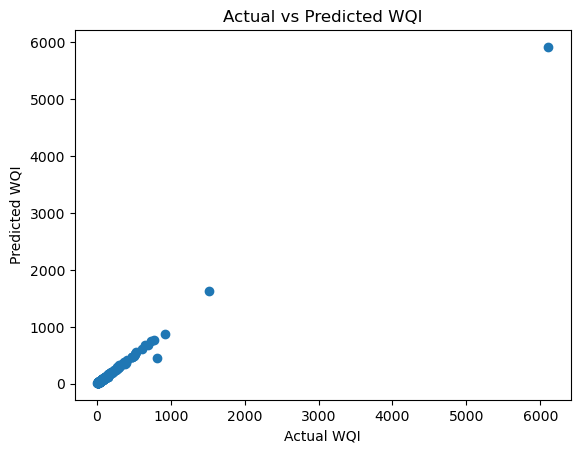

In [97]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual WQI")
plt.ylabel("Predicted WQI")
plt.title("Actual vs Predicted WQI")
plt.show()

In [98]:
import joblib

joblib.dump(model, 'wqi_model1.pkl')

['wqi_model1.pkl']

In [99]:
print(X.columns.tolist())

['Temp', 'DO', 'PH', 'BOD', 'Tot_col']


In [100]:
print(X.mean())

Temp           26.230351
DO              6.357434
PH              7.228192
BOD             6.751246
Tot_col    522400.506056
dtype: float64
